In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict, train_test_split
from sklearn.metrics import mean_squared_error

In [ ]:
#Q1) linear regression assumptions (know all 5, especially homoscedasticity)
#1. Errors are correlated
#2. There is a relationship between X and y
#3. Homoscedacity
#4. Multicollinearly is not there
#5. Outliers are not present in the dataset

In [2]:
data = pd.read_csv('housing.csv')
data.shape

(20640, 10)

In [3]:
#Removing outliers
p_25, p_75 = np.percentile(data['median_house_value'], 25), np.percentile(data['median_house_value'], 75)

IQR = p_75 - p_25
cut_off = 1.5 * IQR
lower_bound = p_25 - cut_off
upper_bound = p_75 + cut_off

def classify(median_house_value):
    if median_house_value < lower_bound:
        return True
    elif median_house_value > upper_bound:
        return True
    else:
        return False

data['is_outlier'] = data['median_house_value'].apply(classify)

data = data[data['is_outlier'] == False]

data['median_house_value'] = data['median_house_value']/100000

In [4]:
data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,is_outlier
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,4.526,NEAR BAY,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,3.585,NEAR BAY,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,3.521,NEAR BAY,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,3.413,NEAR BAY,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,3.422,NEAR BAY,False


In [6]:
X = data.drop(columns=['median_house_value'])
y = data['median_house_value']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

numeric_features = ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
X_train[numeric_features] = X_train[numeric_features].fillna(X_train[numeric_features].median())
X_test[numeric_features] = X_test[numeric_features].fillna(X_test[numeric_features].median())

sc = StandardScaler()
X_train[numeric_features] = sc.fit_transform(X_train[numeric_features])
X_test[numeric_features] = sc.transform(X_test[numeric_features])

categorical_features = ['ocean_proximity']
X_train[categorical_features] = X_train[categorical_features].fillna(X_train[categorical_features].mode().iloc[0])
X_test[categorical_features] = X_test[categorical_features].fillna(X_train[categorical_features].mode().iloc[0])

X_train = pd.get_dummies(X_train, columns = categorical_features, dtype=int, drop_first = True)
X_test = pd.get_dummies(X_test, columns = categorical_features, dtype=int, drop_first = True)

X_train.drop(columns = ['is_outlier', 'ocean_proximity_ISLAND'], inplace = True)
X_test.drop(columns = ['is_outlier'], inplace = True)

In [7]:
#Q1) Train linear regression, Ridge, and Lasso
linear_model = LinearRegression().fit(X_train, y_train)
out = linear_model.predict(X_test)
linear_error = mean_squared_error(y_true = y_test, y_pred = out)

print("Root Mean Squared Error for Linear Regression", np.sqrt(linear_error))

ridge_model = Ridge(alpha = 0.01).fit(X_train, y_train)
out = ridge_model.predict(X_test)
ridge_error = mean_squared_error(y_true = y_test, y_pred = out)
print("Ridge features", ridge_model.coef_)

print("Root Mean Squared Error for Ridge Regression", np.sqrt(ridge_error))

lasso_model = Lasso(alpha = 0.01).fit(X_train, y_train)
out = lasso_model.predict(X_test)
lasso_error = mean_squared_error(y_true = y_test, y_pred = out)
print("Lasso features", lasso_model.coef_)

print("Root Mean Squared Error for Lasso Regression", np.sqrt(lasso_error))

Root Mean Squared Error for Linear Regression 0.5977798331274152
Ridge features [-0.48258173 -0.47801928  0.1042729  -0.10542265  0.25888607 -0.38900454
  0.28312     0.57210168 -0.39642311 -0.08699624  0.02979879]
Root Mean Squared Error for Ridge Regression 0.5977796467292572
Lasso features [-0.26442656 -0.25979646  0.09651776 -0.          0.14647041 -0.2857236
  0.19136349  0.5454966  -0.50655577 -0.          0.        ]
Root Mean Squared Error for Lasso Regression 0.5967270727199382


Text(0, 0.5, 'Residual')

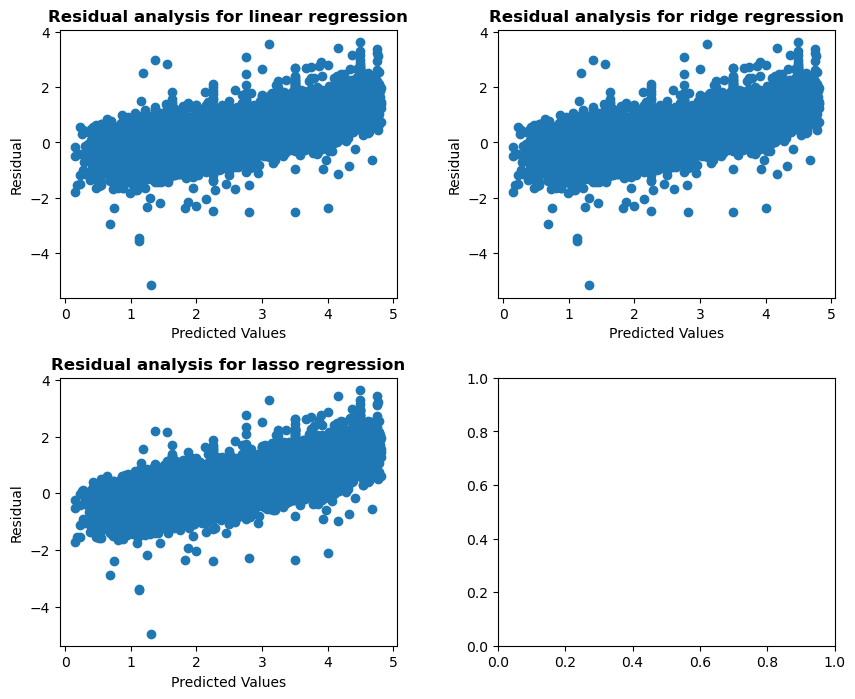

In [8]:
#Q2) Plot residuals for each model

fig, axs = plt.subplots(nrows = 2, ncols = 2)
fig.subplots_adjust(wspace=0.3)
fig.subplots_adjust(hspace=0.3)
fig.set_size_inches(10, 8)

axs[0,0].scatter(y_train, y_train - linear_model.predict(X_train))
axs[0,0].set_title(f'Residual analysis for linear regression',fontweight='bold')
axs[0,0].set_xlabel('Predicted Values')
axs[0,0].set_ylabel('Residual')

axs[0,1].scatter(y_train, y_train - ridge_model.predict(X_train))
axs[0,1].set_title(f'Residual analysis for ridge regression',fontweight='bold')
axs[0,1].set_xlabel('Predicted Values')
axs[0,1].set_ylabel('Residual')

axs[1,0].scatter(y_train, y_train - lasso_model.predict(X_train))
axs[1,0].set_title(f'Residual analysis for lasso regression',fontweight='bold')
axs[1,0].set_xlabel('Predicted Values')
axs[1,0].set_ylabel('Residual')

In [9]:
#Q3) Compare RMSE on the test set
error = pd.DataFrame()
error['Model Name'] = pd.Series(['Linear', 'Ridge', 'Lasso'])
error['RMSE'] = np.sqrt(pd.Series([linear_error, ridge_error, lasso_error]))

error

,Model Name,RMSE
0,Linear,0.597780
1,Ridge,0.597780
2,Lasso,0.596727


In [10]:
#Q4) Identify which features Lasso drives to zero

coefficients = pd.DataFrame()
coefficients['Feature'] = X_train.columns
coefficients['Linear'] = pd.Series(linear_model.coef_)
coefficients['Ridge'] = pd.Series(ridge_model.coef_)
coefficients['Lasso'] = pd.Series(lasso_model.coef_)
coefficients #notice how lasso zero downs the feature, making it fit for feature selection as well.

#The features that lasso drives to zero are longitude, latitude, total_rooms, total_bedrooms, population, households, ocean_proximity_NEAR BAY,
#ocean_proximity_NEAR_OCEAN. However when alpha is reduced to 0.01 (from 0.1) some more features become important except total_rooms etc

,Feature,Linear,Ridge,Lasso
0,longitude,-0.482589,-0.482582,-0.264427
1,latitude,-0.478027,-0.478019,-0.259796
2,housing_median_age,0.104273,0.104273,0.096518
3,total_rooms,-0.105424,-0.105423,-0.000000
4,total_bedrooms,0.258888,0.258886,0.146470
5,population,-0.389007,-0.389005,-0.285724
6,households,0.283122,0.283120,0.191363
7,median_income,0.572102,0.572102,0.545497
8,ocean_proximity_INLAND,-0.396420,-0.396423,-0.506556
9,ocean_proximity_NEAR BAY,-0.086999,-0.086996,-0.000000
